In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

# Problema 1 

In [44]:
BLUE_POS = 2
GREEN_POS = 1
RED_POS = 0

def get_especific_color(pixel, color:int, position:int = -1):
    if(position > -1 and position < 3):
        return pixel[position]
    
    blue = pixel[BLUE_POS]
    red = pixel[RED_POS]
    green = pixel[GREEN_POS]

    match color:
        case 1:
            return [0, 0, blue] 
        case 2:
            return [0, green, 0]
        case 3:
            return [red, 0, 0]
        case 10:
            return [red, green, 0]
        case 20:
            return [0, green, blue]
        case 30:
            return [red, 0, blue]
        case _:
            raise ValueError("Esa opcion de color no existe")


def convert_img(img, color:int):

    alto = img.shape[0]
    ancho = img.shape[1]

    output_img = np.zeros_like(img)

    for h in range(0,alto):
        for w in range(0,ancho):
            pixel = img[h,w]

            output_img[h,w] = get_especific_color(pixel, color)

    plt.imshow(output_img)



# Problema 2

In [30]:
# escala de gris en 3D a color

def gray_to_color(dir_img:str, name_img):
    dir_blue = f"{dir_img}/{name_img}_salida_gray_azul.jpg"
    dir_green = f"{dir_img}/{name_img}_salida_gray_verde.jpg"
    dir_red = f"{dir_img}/{name_img}_salida_gray_rojo.jpg"

    img_azul  = cv2.imread(dir_blue, cv2.IMREAD_GRAYSCALE)
    img_verde = cv2.imread(dir_green, cv2.IMREAD_GRAYSCALE)
    img_rojo  = cv2.imread(dir_red, cv2.IMREAD_GRAYSCALE)

    img_color = cv2.merge([img_azul, img_verde, img_rojo])

    dir_img_out = f"{dir_img}/{name_img}_color.jpg"
    cv2.imwrite(dir_img_out, img_color)

    print(f"Imagenes convertidas correctamente a imagen 'dir_img_out.jpg'")





In [33]:
dir_img = "imagen1"
name_img = "imagen1"

gray_to_color(dir_img, name_img)

Imagenes convertidas correctamente a imagen 'dir_img_out.jpg'


# Problema 3

In [22]:
# color a gris 3D

def color_to_gray_3d(dir_img:str, new_dir:str, name_img:str):
    img = cv2.imread(dir_img)
    
    dim_blue, dim_green, dim_red = cv2.split(img)
    
    os.makedirs(new_dir, exist_ok=True)


    dir_blue  = os.path.join(new_dir, f"{name_img}_blue_to_gray.jpg")
    dir_green = os.path.join(new_dir, f"{name_img}_green_to_gray.jpg")
    dir_red  = os.path.join(new_dir, f"{name_img}_red_to_gray.jpg")


    cv2.imwrite(dir_blue, dim_blue)
    cv2.imwrite(dir_green, dim_green)
    cv2.imwrite(dir_red, dim_red)

    print(f"Imágenes guardadas correctamente en: {new_dir}")
    

In [23]:
new_dir = 'problema_3'
dir_img = f'{new_dir}/noche_estrellada.jpg'
name_img = 'starrynight'


color_to_gray_3d(dir_img, new_dir, name_img)

Imágenes guardadas correctamente en: problema_3


# Problema 4

In [61]:
def gray_by_aritmetic_mean(r, g, b) :
    return int((int(r) + int(g) + int(b)) / 3)


def show_histo(canals):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs = axs.ravel()

    for ax, (nombre, (canal, color)) in zip(axs, canals.items()):
        
        frecuencias = np.bincount(canal.ravel(), minlength=256)
        niveles = np.arange(256)

        media = canal.mean() 

        ax.bar(niveles, frecuencias, color=color, width=1.0)
        ax.axvline(media, color="black", linestyle="--", linewidth=1.5,
                   label=f"Media = {media:.2f}")
        ax.set_title(f"Histograma canal {nombre}")
        ax.set_xlabel("Nivel de intensidad")
        ax.set_ylabel("Frecuencia")
        ax.set_xlim([0, 255])
        ax.legend()

    plt.tight_layout()
    plt.show()

def get_layers_img(dir_img, method_gray):

    img = cv2.imread(dir_img)


    alto = img.shape[0]
    ancho = img.shape[1]

    blue = np.zeros((alto, ancho, 1))
    green = np.zeros((alto, ancho, 1))
    red = np.zeros((alto, ancho, 1))

    gray = np.zeros((alto, ancho, 1))

    for h in range(0,alto):
        for w in range(0,ancho):
            pixel = img[h,w]

            b = get_especific_color(pixel, None, BLUE_POS)
            g = get_especific_color(pixel, None, GREEN_POS)
            r = get_especific_color(pixel, None, RED_POS)

            blue[h,w] = b
            green[h,w] = g
            red[h,w] = r

            gray[h, w] =  method_gray(r, g, b)    # resultado del enfoque utilizado
    

    layers = {
        "Azul":  (blue.astype(np.uint8), "blue"),
        "Verde": (green.astype(np.uint8), "green"),
        "Rojo":  (red.astype(np.uint8), "red"),
        "Gris":  (gray.astype(np.uint8), "black"),
    }

    
    return layers


def get_layersHistos(dir_img):

    layers = get_layers_img(dir_img, gray_by_aritmetic_mean)
    show_histo(layers)
    

    dir_img_notext = dir_img.split(".")[0]
    cv2.imwrite(f"{dir_img_notext}_gray.jpg", layers['Gris'][0])
    print("Se genero la escala de grises con media aritmetica de la imagen recibida")




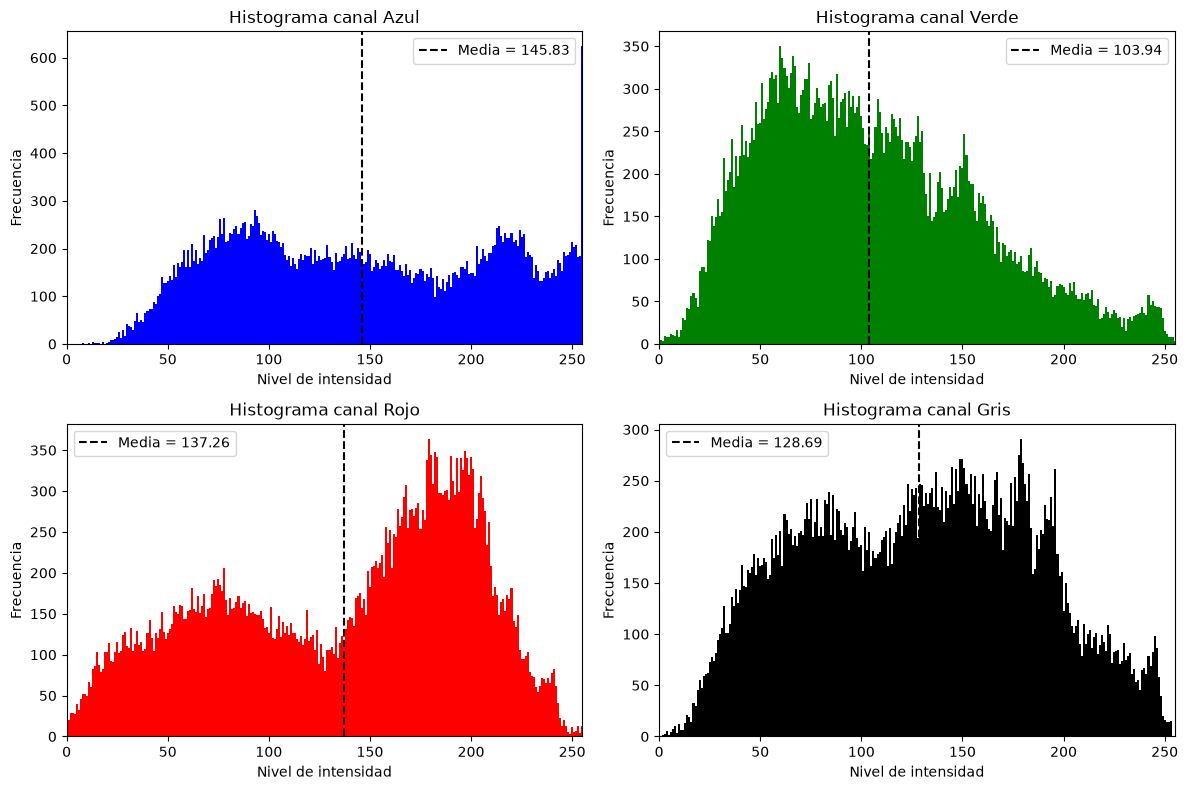

Se genero la escala de grises con media aritmetica de la imagen recibida


In [ ]:
dir_img_4 = 'problema_4/arbol.jpg'

get_layersHistos(dir_img_4)

# Problema 5

Fórmula que asegura que la imagen sea fiel a la luminosidad percibida por el ojo:\(Gris = (0.2126 * Rojo) + (0.7152 * Verde) + (0.0722 * Azul)\)

In [63]:
def weighted_method(r, g, b):
    return int((0.2126 * r) + (0.7152 * g) + (0.0722 * b))

def get_gray_wighted(dir_img):

    layers = get_layers_img(dir_img, weighted_method)

    dir_img_notext = dir_img.split(".")[0]
    cv2.imwrite(f"{dir_img_notext}_weighted_gray.jpg", layers['Gris'][0])
    print("Se genero la escala de grises ponderada de la imagen recibida")


In [65]:
dir_img_5 = 'problema_5/colibri.jpg'

get_gray_wighted(dir_img_5)

Se genero la escala de grises ponderada de la imagen recibida


# Problema  6

# Espacio de color HSV

El espacio de color **HSV** (Hue, Saturation, Value) es una representación de colores que separa la información del color de la intensidad luminosa. A diferencia del modelo RGB, que representa un color mediante la combinación de rojo, verde y azul, HSV describe los colores de una forma más cercana a la percepción humana.

El espacio HSV está compuesto por tres componentes:

- **H (Hue o Tono):** representa el color dominante. Se expresa normalmente como un ángulo en una rueda de colores:
  - 0° corresponde a rojo.
  - 60° a amarillo.
  - 120° a verde.
  - 180° a cian.
  - 240° a azul.
  - 300° a magenta.

- **S (Saturation o Saturación):** indica la pureza o intensidad del color. Un valor de saturación igual a 0 representa tonos grises, mientras que valores altos representan colores más intensos.

- **V (Value o Valor):** representa el brillo del color. Un valor de 0 corresponde al negro y un valor máximo corresponde al color con mayor luminosidad.

---

# Mapeo de colores RGB a HSV

Los colores normalmente se almacenan en formato RGB, donde cada componente tiene valores entre 0 y 255. Para convertir un color RGB a HSV, primero se normalizan los valores:

\[
R' = \frac{R}{255}, \quad G' = \frac{G}{255}, \quad B' = \frac{B}{255}
\]

Luego se calculan los componentes HSV:

## 1. Valor (V)

Se obtiene tomando el valor máximo de los tres canales:

\[
V = max(R',G',B')
\]

---

## 2. Saturación (S)

Se calcula mediante:

\[
S = \frac{max(R',G',B')-min(R',G',B')}{max(R',G',B')}
\]

Si los tres valores RGB son iguales, la saturación es 0 y el color corresponde a una escala de grises.

---

## 3. Tono (H)

El cálculo del tono depende del canal RGB que tenga el valor máximo:

- Si el rojo es el valor máximo:

\[
H = 60 \times \frac{G'-B'}{max-min}
\]

- Si el verde es el valor máximo:

\[
H = 60 \times (2+\frac{B'-R'}{max-min})
\]

- Si el azul es el valor máximo:

\[
H = 60 \times (4+\frac{R'-G'}{max-min})
\]

El resultado se expresa como un ángulo entre 0° y 360°.
